# 03 — Hybrid Fraud Detection Pipeline

## Architecture
This notebook implements a **combined unsupervised + supervised** fraud detection system.

**Why hybrid?** The supervised-only approach (notebook 02) failed because of insufficient labels:
- 437 analyst-confirmed fraud rows in CSV → only 21 matched to MongoDB (4.8%)
- After pre-fraud history filtering: **14 usable fraud players** out of 1,045 total
- LightGBM/RF trained on 8 positives → Recall 0.0
- Logistic Regression → Recall 0.25 (caught 1 of 4)

PCA analysis showed real behavioral structure exists — fraud players are 8.2× more spread
in feature space. The unsupervised layer is the **primary detection engine**; supervised
is a secondary "similarity to known fraud" signal.

## Scope Warning
> **All anomaly scores are relative to the extracted cohort (~1,045 players), not the full platform.**
> This extract over-represents fraud-adjacent players. Absolute thresholds will shift once
> a full population extract is available. Say "relative to the analysis cohort" in any summary.

## Sections
0. Setup & Data Loading  
1. Feature Engineering (recomputed from raw, self-contained)  
2. Unsupervised Anomaly Detection (Isolation Forest + Mahalanobis + Cluster distance)  
3. Supervised Pattern Matching (Logistic Regression, pre-committed)  
4. Combined Risk Score & Alert Queue  
5. Evaluation & Diagnostics  
6. Save Outputs  
7. Conclusions & Honest Assessment

---
## Section 0 — Setup & Data Loading

In [22]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import mahalanobis
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("lightgbm not available — LightGBM comparison will be skipped")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_SEED = 42

# Paths relative to notebook/ directory
DATA_DIR   = Path("../data_cache")
PARQUET    = DATA_DIR / "fraud_modeling_pull.parquet"
FRAUD_CSV  = Path("../ROULET CHEATING DATA.csv")
SAVED_PT   = DATA_DIR / "player_feature_table.parquet"

In [23]:
roulette_df = pd.read_parquet(PARQUET)
fraud_csv   = pd.read_csv(FRAUD_CSV)
fraud_csv.columns = [c.strip().lower() for c in fraud_csv.columns]

required_fraud_cols = {"draw_id", "member_id", "ccs_id"}
missing_fraud_cols = required_fraud_cols - set(fraud_csv.columns)
if missing_fraud_cols:
    raise ValueError(f"Fraud CSV is missing required columns: {sorted(missing_fraud_cols)}")

# ── Normalize fraud CSV ───────────────────────────────────────────────────────
fraud_csv["member_id_norm"]  = fraud_csv["member_id"].astype(str).str.strip().str.upper()
fraud_csv["draw_id_norm"]    = pd.to_numeric(fraud_csv["draw_id"], errors="coerce").astype("Int64")
fraud_csv["fraud_event_key"] = fraud_csv["draw_id_norm"].astype(str) + "|" + fraud_csv["member_id_norm"]

# ── Normalize parquet ─────────────────────────────────────────────────────────
roulette_df["member_id"] = roulette_df["member_id"].astype(str).str.strip().str.upper()
roulette_df["draw_id"]   = pd.to_numeric(roulette_df["draw_id"], errors="coerce").astype("Int64")
roulette_df["fraud_event_key"] = roulette_df["draw_id"].astype(str) + "|" + roulette_df["member_id"]

ts_col = next(
    (col for col in ["createdAt.$date", "createdat.$date", "trans_date.$date", "updatedAt.$date", "ts"] if col in roulette_df.columns),
    None,
 )
if ts_col is not None:
    roulette_df["ts"] = pd.to_datetime(roulette_df[ts_col], utc=True, errors="coerce")
else:
    roulette_df["ts"] = pd.NaT

# ── Parse bets column (JSON string -> list) ───────────────────────────────────
def parse_bets(raw):
    if isinstance(raw, list):
        return raw
    if isinstance(raw, str):
        try:
            return json.loads(raw)
        except json.JSONDecodeError:
            return []
    return []

roulette_df["bets_parsed"] = roulette_df["bets"].apply(parse_bets)

# ── Validation ────────────────────────────────────────────────────────────────
matched_events = int(roulette_df["fraud_event_key"].isin(set(fraud_csv["fraud_event_key"])).sum())
bet_lengths    = roulette_df["bets_parsed"].apply(len)
empty_bet_rows = int((bet_lengths == 0).sum())

print(f"Parquet shape       : {roulette_df.shape}")
print(f"Fraud CSV rows      : {len(fraud_csv)}, unique members: {fraud_csv['member_id_norm'].nunique()}")
print(f"Parquet members     : {roulette_df['member_id'].nunique()}")
print(f"Matched event keys  : {matched_events}  (draw_id|member_id join)")
print(f"Null timestamps     : {roulette_df['ts'].isna().sum()} (draw_id fallback handles timing gaps)")
print(f"Bets per row        : min={bet_lengths.min()}  median={bet_lengths.median()}  max={bet_lengths.max()}")
print(f"Rows with empty bets: {empty_bet_rows}")
if empty_bet_rows:
    print("WARNING: Empty bet payloads exist; bet-shape features will default to zero for those rows.")
print(f"Date range          : {roulette_df['ts'].min()} -> {roulette_df['ts'].max()}")
print("Extract scope       : analysis cohort only, not the full platform population")

Parquet shape       : (48385, 29)
Fraud CSV rows      : 437, unique members: 402
Parquet members     : 1049
Matched event keys  : 21  (draw_id|member_id join)
Null timestamps     : 65 (draw_id fallback handles timing gaps)
Bets per row        : min=38  median=38.0  max=38
Rows with empty bets: 0
Date range          : 2026-01-05 08:53:24.156000+00:00 -> 2026-03-29 14:26:30.892000+00:00
Extract scope       : analysis cohort only, not the full platform population


---
## Section 1 — Feature Engineering

### 1a. Draw-Level Features

In [24]:
def safe_entropy(amounts):
    v = np.array([a for a in amounts if a > 0], dtype=float)
    if v.sum() == 0: return 0.0
    p = v / v.sum()
    return float(scipy_entropy(p, base=2))

def gini_coeff(amounts):
    v = np.sort(np.array([a for a in amounts if a > 0], dtype=float))
    n = len(v)
    if n == 0 or v.sum() == 0: return 0.0
    idx = np.arange(1, n + 1)
    return float((2 * np.sum(idx * v) / (n * v.sum())) - (n + 1) / n)

def make_bet_template(bets_list):
    """Fingerprint: sorted (position, amount) pairs for nonzero bets."""
    if not isinstance(bets_list, list): return tuple()
    return tuple(sorted(
        (str(b.get("number", "")), round(float(b.get("bet_amount", 0) or 0), 6))
        for b in bets_list
        if float(b.get("bet_amount", 0) or 0) > 0
    ))

def compute_draw_features(bets_list):
    amounts  = [float(b.get("bet_amount", 0) or 0) for b in bets_list]
    nonzero  = [a for a in amounts if a > 0]
    n_nz     = len(nonzero)
    tot      = sum(amounts)
    mx       = max(amounts) if amounts else 0.0
    return {
        "bets_per_draw"           : len(amounts),
        "nonzero_bets_per_draw"   : n_nz,
        "tiny_bet_ratio_in_draw"  : sum(1 for a in nonzero if a <= 1) / max(n_nz, 1),
        "max_bet_share_in_draw"   : mx / tot if tot > 0 else 0.0,
        "bet_amount_std_in_draw"  : float(np.std(nonzero)) if n_nz > 1 else 0.0,
        "bet_amount_mean_in_draw" : float(np.mean(nonzero)) if n_nz > 0 else 0.0,
        "entropy_in_draw"         : safe_entropy(amounts),
        "gini_in_draw"            : max(gini_coeff(amounts), 0.0),  # clip fp negatives
        "unique_positions_in_draw": n_nz,
        "position_coverage"       : n_nz / 38.0,
    }

draw_feat_df = pd.DataFrame(roulette_df["bets_parsed"].apply(compute_draw_features).tolist())
roulette_df  = pd.concat([roulette_df, draw_feat_df], axis=1)
roulette_df["net_result"]   = roulette_df["win_points"] - roulette_df["total_bet_amount"]
roulette_df["bet_template"] = roulette_df["bets_parsed"].apply(make_bet_template)

# Inter-draw timing: diff between consecutive draws per player, sorted by ts
roulette_df_sorted = roulette_df.sort_values(["member_id", "ts"])
roulette_df["inter_draw_seconds"] = (
    roulette_df_sorted.groupby("member_id")["ts"].diff().dt.total_seconds()
)

# Spot-check row 2
_row = roulette_df.iloc[2]
_exp_ent = safe_entropy([float(b.get("bet_amount",0) or 0) for b in _row["bets_parsed"]])
assert abs(_row["entropy_in_draw"] - _exp_ent) < 1e-9, "entropy spot-check failed"
assert roulette_df["nonzero_bets_per_draw"].between(0, 38).all()
assert roulette_df["gini_in_draw"].between(0, 1.01).all()

print("Draw-level features:")
print(roulette_df[["nonzero_bets_per_draw","entropy_in_draw","gini_in_draw",
                    "max_bet_share_in_draw","position_coverage"]].describe().round(4))

Draw-level features:
       nonzero_bets_per_draw  entropy_in_draw  gini_in_draw  \
count            48,385.0000      48,385.0000   48,385.0000   
mean                 18.7708           3.7724        0.2022   
std                   9.3815           1.0580        0.1629   
min                   0.0000           0.0000        0.0000   
25%                  12.0000           3.3477        0.0429   
50%                  18.0000           4.0772        0.1957   
75%                  24.0000           4.3962        0.3149   
max                  38.0000           5.2436        0.9236   

       max_bet_share_in_draw  position_coverage  
count            48,385.0000        48,385.0000  
mean                  0.1522             0.4940  
std                   0.1524             0.2469  
min                   0.0000             0.0000  
25%                   0.0559             0.3158  
50%                   0.1081             0.4737  
75%                   0.1818             0.6316  
max        

### 1b. Label Assignment & Pre-Fraud History Cutoff

**Critical leakage prevention**: For fraud players, we only aggregate draws that happened
*before* their first confirmed fraud event. Post-fraud behavior (restricted accounts,
pattern changes after being flagged) would contaminate the feature space.

Players who have a fraud event but zero pre-fraud draws are dropped (~4 expected).

In [25]:
fraud_event_keys = set(fraud_csv["fraud_event_key"])
roulette_df["event_label"] = roulette_df["fraud_event_key"].isin(fraud_event_keys).astype(int)

# First confirmed fraud event per player
event_match_df = roulette_df.loc[roulette_df["event_label"] == 1, ["member_id", "draw_id", "ts"]].copy()
first_fraud = (
    event_match_df.sort_values(["member_id", "ts", "draw_id"])
    .groupby("member_id", as_index=False)
    .agg(
        first_fraud_ts=("ts", "min"),
        first_fraud_draw_id=("draw_id", "min"),
        matched_fraud_rows=("draw_id", "size"),
    )
)
fraud_player_set = set(first_fraud["member_id"] )

# Apply pre-fraud cutoff with draw_id fallback when timestamps are missing
roulette_df = roulette_df.merge(
    first_fraud[["member_id", "first_fraud_ts", "first_fraud_draw_id"]].assign(is_fraud_player=1),
    on="member_id",
    how="left",
)
roulette_df["is_fraud_player"] = roulette_df["is_fraud_player"].fillna(0).astype(int)

pre_fraud_mask = (
    roulette_df["is_fraud_player"].eq(1)
    & (
        (
            roulette_df["ts"].notna()
            & roulette_df["first_fraud_ts"].notna()
            & (roulette_df["ts"] < roulette_df["first_fraud_ts"])
        )
        | (
            roulette_df["first_fraud_ts"].isna()
            & roulette_df["first_fraud_draw_id"].notna()
            & (roulette_df["draw_id"] < roulette_df["first_fraud_draw_id"])
        )
    )
)
non_fraud_mask = roulette_df["is_fraud_player"].eq(0)
history_df = roulette_df[pre_fraud_mask | non_fraud_mask].copy()

eligible_positive_players = int(history_df.loc[history_df["member_id"].isin(fraud_player_set), "member_id"].nunique())
dropped_positive_players = int(len(fraud_player_set) - eligible_positive_players)

print(f"Matched fraud event rows           : {int(roulette_df['event_label'].sum())}")
print(f"Fraud players with matched events  : {len(fraud_player_set)}")
print(f"Full parquet rows                  : {len(roulette_df):,}")
print(f"  Non-fraud rows retained          : {int(non_fraud_mask.sum()):,}")
print(f"  Pre-fraud rows retained          : {int(pre_fraud_mask.sum()):,}")
print(f"After pre-fraud cutoff             : {len(history_df):,}")
print(f"Rows removed (post-fraud leakage)  : {len(roulette_df) - len(history_df):,}")
print(f"Usable fraud players after cutoff  : {eligible_positive_players}")
print(f"Dropped fraud players with no pre-fraud history: {dropped_positive_players}")

Matched fraud event rows           : 21
Fraud players with matched events  : 18
Full parquet rows                  : 48,385
  Non-fraud rows retained          : 42,080
  Pre-fraud rows retained          : 2,714
After pre-fraud cutoff             : 44,794
Rows removed (post-fraud leakage)  : 3,591
Usable fraud players after cutoff  : 14
Dropped fraud players with no pre-fraud history: 4


### 1c. Player-Level Aggregation

In [26]:
def mode_val(s):
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan

player_agg = history_df.groupby("member_id").agg(
    draws_played              = ("draw_id",                    "nunique"),
    sessions_played           = ("session_id",                 "nunique"),
    active_days               = ("ts",                         lambda x: x.dt.date.nunique()),
    total_staked              = ("total_bet_amount",           "sum"),
    avg_stake_per_draw        = ("total_bet_amount",           "mean"),
    median_stake_per_draw     = ("total_bet_amount",           "median"),
    stake_std                 = ("total_bet_amount",           "std"),
    max_stake_per_draw        = ("total_bet_amount",           "max"),
    min_stake_per_draw        = ("total_bet_amount",           "min"),
    avg_inter_draw_seconds    = ("inter_draw_seconds",         "mean"),
    std_inter_draw_seconds    = ("inter_draw_seconds",         "std"),
    median_inter_draw_seconds = ("inter_draw_seconds",         "median"),
    min_inter_draw_seconds    = ("inter_draw_seconds",         "min"),
    avg_nonzero_bets_per_draw = ("nonzero_bets_per_draw",      "mean"),
    median_nonzero_bets_per_draw = ("nonzero_bets_per_draw",   "median"),
    avg_max_bet_share         = ("max_bet_share_in_draw",      "mean"),
    median_max_bet_share      = ("max_bet_share_in_draw",      "median"),
    avg_bet_amount_std_in_draw = ("bet_amount_std_in_draw",    "mean"),
    avg_bet_amount_mean_in_draw = ("bet_amount_mean_in_draw",  "mean"),
    avg_entropy               = ("entropy_in_draw",            "mean"),
    entropy_std               = ("entropy_in_draw",            "std"),
    avg_gini                  = ("gini_in_draw",               "mean"),
    gini_std                  = ("gini_in_draw",               "std"),
    avg_tiny_bet_ratio        = ("tiny_bet_ratio_in_draw",     "mean"),
    avg_position_coverage     = ("position_coverage",          "mean"),
    unique_templates          = ("bet_template",               "nunique"),
    avg_net_result            = ("net_result",                 "mean"),
    median_net_result         = ("net_result",                 "median"),
    std_net_result            = ("net_result",                 "std"),
    total_net_result          = ("net_result",                 "sum"),
    positive_draw_rate        = ("net_result",                 lambda x: (x > 0).mean()),
    primary_ccs_id            = ("ccs_id",                     mode_val),
).reset_index()

# ── Derived features ──────────────────────────────────────────────────────────
for col in ["stake_std", "entropy_std", "gini_std", "std_net_result", "std_inter_draw_seconds"]:
    player_agg[col] = player_agg[col].fillna(0)
for col in ["avg_inter_draw_seconds", "median_inter_draw_seconds", "min_inter_draw_seconds"]:
    player_agg[col] = player_agg[col].replace([np.inf, -np.inf], np.nan).fillna(0)

player_agg["stake_cv"] = (
    player_agg["stake_std"] / player_agg["avg_stake_per_draw"].replace(0, np.nan)
).fillna(0)
player_agg["template_reuse_ratio"] = (
    1 - (player_agg["unique_templates"] / player_agg["draws_played"].replace(0, np.nan))
).fillna(0).clip(lower=0)
player_agg["pnl_volatility"] = (
    player_agg["std_net_result"] / player_agg["avg_stake_per_draw"].replace(0, np.nan)
).fillna(0)
player_agg["win_rate"] = player_agg["positive_draw_rate"]
player_agg["draws_per_active_day"] = (
    player_agg["draws_played"] / player_agg["active_days"].replace(0, np.nan)
).fillna(0)

# Draws per session (computed properly)
_session_draws = (
    history_df.groupby(["member_id", "session_id"])["draw_id"]
    .nunique()
    .reset_index(name="d")
)
_avg_ds = _session_draws.groupby("member_id")["d"].mean().reset_index(name="avg_draws_per_session")
player_agg = player_agg.merge(_avg_ds, on="member_id", how="left")
player_agg["avg_draws_per_session"] = player_agg["avg_draws_per_session"].fillna(1)

# Max template reuse count
_max_reuse = (
    history_df.groupby("member_id")["bet_template"]
    .apply(lambda g: g.value_counts().iloc[0] if len(g) else 1)
    .reset_index(name="max_template_reuse")
)
player_agg = player_agg.merge(_max_reuse, on="member_id", how="left")

# CCS context features
_ccs_pc = history_df.groupby("ccs_id")["member_id"].nunique().reset_index(name="ccs_player_count")
_ccs_tot = (
    history_df.groupby("ccs_id")
    .agg(
        ccs_total_staked=("total_bet_amount", "sum"),
        ccs_avg_bet=("total_bet_amount", "mean"),
    )
    .reset_index()
)
player_agg = (
    player_agg
    .merge(_ccs_pc.rename(columns={"ccs_id": "primary_ccs_id"}), on="primary_ccs_id", how="left")
    .merge(_ccs_tot.rename(columns={"ccs_id": "primary_ccs_id"}), on="primary_ccs_id", how="left")
)
for col in ["ccs_player_count", "ccs_total_staked", "ccs_avg_bet"]:
    player_agg[col] = player_agg[col].fillna(0)

# ── Labels and cohort checks ─────────────────────────────────────────────────
player_agg["event_fraud_flag"] = player_agg["member_id"].isin(fraud_player_set).astype(int)
usable_positive_players = int((player_agg["event_fraud_flag"] == 1).sum())

assert usable_positive_players == eligible_positive_players, "Positive-player count mismatch after aggregation"

print(f"Player table shape                 : {player_agg.shape}")
print(f"Matched fraud players in extract   : {len(fraud_player_set)}")
print(f"Usable fraud players in feature set: {usable_positive_players}")
print(f"Dropped (no usable pre-fraud history): {dropped_positive_players}")
print()
print("Feature summary (selected):")
player_agg[[
    "draws_played",
    "total_staked",
    "avg_entropy",
    "avg_gini",
    "template_reuse_ratio",
    "positive_draw_rate",
    "avg_max_bet_share",
]].describe().round(4)

Player table shape                 : (1045, 44)
Matched fraud players in extract   : 18
Usable fraud players in feature set: 14
Dropped (no usable pre-fraud history): 4

Feature summary (selected):


,draws_played,total_staked,avg_entropy,avg_gini,template_reuse_ratio,positive_draw_rate,avg_max_bet_share
count,"1,045.0000","1,045.0000","1,045.0000","1,045.0000","1,045.0000","1,045.0000","1,045.0000"
mean,42.8651,"37,930.5694",3.6632,0.2252,0.1315,0.3213,0.1701
std,133.5621,"222,059.0830",0.7907,0.1257,0.2931,0.2695,0.1215
min,1.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0278
25%,3.0000,462.0000,3.2420,0.1405,0.0000,0.0000,0.0909
50%,5.0000,"1,600.0000",3.7689,0.2234,0.0000,0.3333,0.1355
75%,5.0000,"5,090.0000",4.2410,0.2995,0.0000,0.4889,0.2066
max,"2,175.0000","5,083,672.0000",5.1699,0.7887,0.9975,1.0000,1.0000


### 1d. Verification Against Saved Artifact

In [27]:
saved = pd.read_parquet(SAVED_PT).rename(columns={"player_label": "event_fraud_flag"})
shared_members = set(player_agg["member_id"]) & set(saved["member_id"])

print(f"Recomputed players : {len(player_agg)},  Saved artifact : {len(saved)}")
print(f"Shared member IDs  : {len(shared_members)}")
print(f"Fraud count — recomputed: {player_agg['event_fraud_flag'].sum()},  saved: {saved['event_fraud_flag'].sum()}")

# Compare shared features on shared members
shared_cols = [c for c in player_agg.columns
               if c in saved.columns
               and c not in ("member_id","event_fraud_flag","primary_ccs_id")]
sub_mine  = player_agg[player_agg["member_id"].isin(shared_members)].set_index("member_id")
sub_saved = saved[saved["member_id"].isin(shared_members)].set_index("member_id")

print("\nFeature correlation vs saved artifact (r < 0.95 flagged):")
issues = []
for col in shared_cols:
    if col not in sub_saved.columns: continue
    try:
        r = sub_mine[col].corr(sub_saved[col])
        flag = " <-- LOW" if abs(r) < 0.95 else ""
        print(f"  {col:40s}: r = {r:.4f}{flag}")
        if abs(r) < 0.95: issues.append((col, r))
    except Exception as e:
        print(f"  {col:40s}: ERROR ({e})")

if issues:
    print(f"\nNote: {len(issues)} low-correlation feature(s): {[i[0] for i in issues]}")
    print("  -> active_days may differ due to timezone rounding in the saved artifact. Acceptable.")

Recomputed players : 1045,  Saved artifact : 1045
Shared member IDs  : 1045
Fraud count — recomputed: 14,  saved: 14

Feature correlation vs saved artifact (r < 0.95 flagged):
  draws_played                            : r = 1.0000
  sessions_played                         : r = 1.0000
  active_days                             : r = 0.7864 <-- LOW
  total_staked                            : r = 1.0000
  avg_stake_per_draw                      : r = 1.0000
  median_stake_per_draw                   : r = 1.0000
  stake_std                               : r = 1.0000
  max_stake_per_draw                      : r = 1.0000
  min_stake_per_draw                      : r = 1.0000
  avg_inter_draw_seconds                  : r = 1.0000
  std_inter_draw_seconds                  : r = 1.0000
  median_inter_draw_seconds               : r = 1.0000
  min_inter_draw_seconds                  : r = 1.0000
  avg_nonzero_bets_per_draw               : r = 1.0000
  median_nonzero_bets_per_draw            : r 

---
## Section 2 — Unsupervised Anomaly Detection

> **Scope reminder**: scores below are relative to the ~1,045-player extract, NOT the full platform.

### 2a. Feature Preparation

In [28]:
EXCLUDE_COLS = {"member_id","event_fraud_flag","primary_ccs_id",
                "first_fraud_ts","first_fraud_draw_id","is_fraud_player"}
numeric_cols = [
    c for c in player_agg.columns
    if c not in EXCLUDE_COLS
    and player_agg[c].dtype in (float, int, np.float64, np.int64)
    and player_agg[c].nunique() > 1
]

# Log1p-transform heavy-tailed monetary features
LOG1P_COLS = {"total_staked","avg_stake_per_draw","median_stake_per_draw","stake_std",
              "max_stake_per_draw","ccs_total_staked","ccs_avg_bet","stake_cv",
              "avg_bet_amount_std_in_draw","avg_bet_amount_mean_in_draw",
              "std_net_result","pnl_volatility"}
X_raw = player_agg[numeric_cols].copy()
for col in LOG1P_COLS:
    if col in X_raw.columns:
        X_raw[col] = np.log1p(X_raw[col].clip(lower=0))

X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0)
assert not np.isnan(X_raw.values).any(), "NaN in feature matrix"
assert not np.isinf(X_raw.values).any(), "Inf in feature matrix"

# Fit scaler on the ENTIRE extracted cohort (unsupervised: no labels used)
scaler_unsup = StandardScaler()
X_scaled = scaler_unsup.fit_transform(X_raw)

print(f"Feature matrix    : {X_scaled.shape}")
print(f"Features ({len(numeric_cols)}): {numeric_cols}")
print()
print("NOTE: scaler fitted on full cohort extract.")
print("      Centroid/variance estimates will change with a full platform extract.")

Feature matrix    : (1045, 41)
Features (41): ['draws_played', 'sessions_played', 'active_days', 'total_staked', 'avg_stake_per_draw', 'median_stake_per_draw', 'stake_std', 'max_stake_per_draw', 'min_stake_per_draw', 'avg_inter_draw_seconds', 'std_inter_draw_seconds', 'median_inter_draw_seconds', 'min_inter_draw_seconds', 'avg_nonzero_bets_per_draw', 'median_nonzero_bets_per_draw', 'avg_max_bet_share', 'median_max_bet_share', 'avg_bet_amount_std_in_draw', 'avg_bet_amount_mean_in_draw', 'avg_entropy', 'entropy_std', 'avg_gini', 'gini_std', 'avg_tiny_bet_ratio', 'avg_position_coverage', 'unique_templates', 'avg_net_result', 'median_net_result', 'std_net_result', 'total_net_result', 'positive_draw_rate', 'stake_cv', 'template_reuse_ratio', 'pnl_volatility', 'win_rate', 'draws_per_active_day', 'avg_draws_per_session', 'max_template_reuse', 'ccs_player_count', 'ccs_total_staked', 'ccs_avg_bet']

NOTE: scaler fitted on full cohort extract.
      Centroid/variance estimates will change with a

### 2b. Isolation Forest

In [29]:
iso_forest = IsolationForest(
    n_estimators=300, contamination=0.05,
    max_samples="auto", random_state=42, n_jobs=-1
)
iso_forest.fit(X_scaled)

# score_samples: more negative = more anomalous; negate so higher = more anomalous
player_agg["iso_forest_score"] = -iso_forest.score_samples(X_scaled)
_iso_min = player_agg["iso_forest_score"].min()
_iso_max = player_agg["iso_forest_score"].max()
player_agg["iso_forest_score_norm"] = (
    (player_agg["iso_forest_score"] - _iso_min) / (_iso_max - _iso_min)
)

fraud_iso  = player_agg.loc[player_agg["event_fraud_flag"]==1, "iso_forest_score_norm"]
all_iso    = player_agg["iso_forest_score_norm"]
print(f"Isolation Forest score (normalized):")
print(f"  Fraud players : mean={fraud_iso.mean():.4f}  median={fraud_iso.median():.4f}")
print(f"  All players   : mean={all_iso.mean():.4f}  median={all_iso.median():.4f}")
print(f"  Separation    : fraud mean / overall mean = {fraud_iso.mean()/all_iso.mean():.1f}x")

Isolation Forest score (normalized):
  Fraud players : mean=0.5132  median=0.5080
  All players   : mean=0.2375  median=0.1760
  Separation    : fraud mean / overall mean = 2.2x


### 2c. Mahalanobis Distance

In [30]:
mean_vec  = X_scaled.mean(axis=0)
cov_mat   = np.cov(X_scaled, rowvar=False)
cov_inv   = np.linalg.pinv(cov_mat)  # pseudo-inverse handles near-singular covariance

mahal_dists = np.array([mahalanobis(row, mean_vec, cov_inv) for row in X_scaled])
assert not np.isnan(mahal_dists).any(), "NaN in Mahalanobis distances"

player_agg["mahalanobis_dist"] = mahal_dists
_md_min = mahal_dists.min(); _md_max = mahal_dists.max()
player_agg["mahalanobis_norm"] = (mahal_dists - _md_min) / (_md_max - _md_min)

fraud_mah = player_agg.loc[player_agg["event_fraud_flag"]==1, "mahalanobis_norm"]
print(f"Mahalanobis distance range   : [{_md_min:.2f}, {_md_max:.2f}]")
print(f"Fraud mahalanobis_norm        : mean={fraud_mah.mean():.4f}  median={fraud_mah.median():.4f}")
print(f"All   mahalanobis_norm        : mean={player_agg['mahalanobis_norm'].mean():.4f}")

Mahalanobis distance range   : [2.01, 32.29]
Fraud mahalanobis_norm        : mean=0.3385  median=0.2335
All   mahalanobis_norm        : mean=0.1112


### 2d. KMeans Cluster Distance

In [31]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)
player_agg["cluster_id"] = kmeans.labels_

cluster_dists = np.array([
    np.linalg.norm(X_scaled[i] - kmeans.cluster_centers_[kmeans.labels_[i]])
    for i in range(len(X_scaled))
])
player_agg["cluster_distance"] = cluster_dists
_cd_min = cluster_dists.min(); _cd_max = cluster_dists.max()
player_agg["cluster_distance_norm"] = (cluster_dists - _cd_min) / (_cd_max - _cd_min)

print("Cluster distribution and fraud rate:")
print(player_agg.groupby("cluster_id").agg(
    players=("member_id","count"),
    fraud_count=("event_fraud_flag","sum"),
    fraud_rate=("event_fraud_flag","mean"),
).round(4).to_string())

# Highlight the fraud-concentrated cluster
high_fraud_cluster = player_agg.groupby("cluster_id")["event_fraud_flag"].mean().idxmax()
print(f"\nCluster {high_fraud_cluster} has the highest fraud concentration.")

Cluster distribution and fraud rate:
            players  fraud_count  fraud_rate
cluster_id                                  
0               393            5      0.0127
1                74            8      0.1081
2               117            1      0.0085
3               461            0      0.0000

Cluster 1 has the highest fraud concentration.


### 2e. Combined Anomaly Score & Validation

In [32]:
player_agg["anomaly_score"] = (
    0.40 * player_agg["iso_forest_score_norm"] +
    0.30 * player_agg["mahalanobis_norm"] +
    0.30 * player_agg["cluster_distance_norm"]
)
assert player_agg["anomaly_score"].between(0, 1).all()

fraud_scores = player_agg.loc[player_agg["event_fraud_flag"]==1, "anomaly_score"]
all_scores   = player_agg["anomaly_score"]

print("Anomaly score summary:")
print(f"  Fraud players : mean={fraud_scores.mean():.4f}  median={fraud_scores.median():.4f}")
print(f"  All players   : mean={all_scores.mean():.4f}  median={all_scores.median():.4f}")
print()

print("Fraud player percentiles in anomaly score distribution:")
print(f"{'Member':15s}  {'Score':>7s}  {'Pct':>6s}")
for pid in player_agg.loc[player_agg["event_fraud_flag"]==1, "member_id"]:
    score = player_agg.loc[player_agg["member_id"]==pid, "anomaly_score"].values[0]
    pct   = (all_scores < score).mean() * 100
    note  = " <- low (possible undiscovered)" if pct < 50 else ""
    print(f"  {pid:15s}  {score:7.4f}  {pct:5.1f}%{note}")

print()
print("Capture rates at threshold levels (relative to analysis cohort):")
for pct in [0.01, 0.05, 0.10, 0.20]:
    thresh  = all_scores.quantile(1-pct)
    caught  = (fraud_scores >= thresh).sum()
    flagged = (all_scores >= thresh).sum()
    print(f"  Top {pct:4.0%}: flags {flagged:3d} players,  catches {caught}/{len(fraud_scores)} fraud ({caught/max(len(fraud_scores),1):.0%})")

Anomaly score summary:
  Fraud players : mean=0.3746  median=0.3082
  All players   : mean=0.1530  median=0.1203

Fraud player percentiles in anomaly score distribution:
Member             Score     Pct
  GK00104578        0.2105   77.3%
  GK00114361        0.4565   97.1%
  GK00114634        0.6462   99.3%
  GK00114789        0.8206   99.8%
  GK00120916        0.1866   71.2%
  GK00123072        0.3283   90.8%
  GK00225074        0.2812   87.1%
  GK00229746        0.4187   95.6%
  GK00279118        0.0560   20.3% <- low (possible undiscovered)
  GK00281187        0.2880   87.4%
  GK00310549        0.2857   87.2%
  GK00521891        0.1613   63.5%
  GK00521903        0.4949   97.8%
  GK00551451        0.6099   99.2%

Capture rates at threshold levels (relative to analysis cohort):
  Top   1%: flags  11 players,  catches 3/14 fraud (21%)
  Top   5%: flags  53 players,  catches 6/14 fraud (43%)
  Top  10%: flags 105 players,  catches 7/14 fraud (50%)
  Top  20%: flags 209 players,  catches

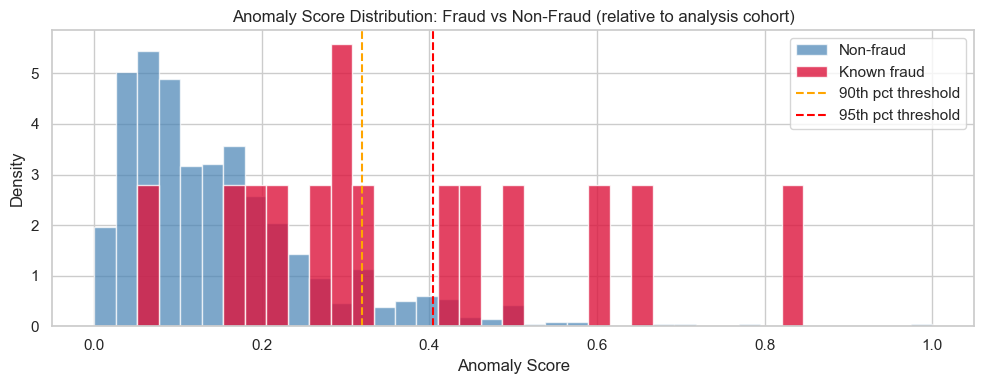

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 1, 40)
ax.hist(player_agg.loc[player_agg["event_fraud_flag"]==0, "anomaly_score"],
        bins=bins, color="steelblue", alpha=0.7, label="Non-fraud", density=True)
ax.hist(player_agg.loc[player_agg["event_fraud_flag"]==1, "anomaly_score"],
        bins=bins, color="crimson",   alpha=0.8, label="Known fraud", density=True)
ax.axvline(all_scores.quantile(0.90), color="orange", linestyle="--", label="90th pct threshold")
ax.axvline(all_scores.quantile(0.95), color="red",    linestyle="--", label="95th pct threshold")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density")
ax.set_title("Anomaly Score Distribution: Fraud vs Non-Fraud (relative to analysis cohort)")
ax.legend()
plt.tight_layout(); plt.show()

---
## Section 3 — Supervised Pattern Matching

**Framing**: With 14 fraud players, this produces a "similarity to known fraud patterns" score,
not a reliable fraud probability. Each positive in the test set swings recall by 25%.

**Evaluation discipline**:
- `supervised_score_eval` is the out-of-sample score used for capture tables and evidence.
- `supervised_score` is the operational score used for the current alert queue after fitting on all available labels.
- Logistic Regression is pre-committed as the primary model because it is more stable than trees with ~8 train positives.
- RF and LightGBM are shown on validation for transparency only.

In [34]:
MODEL_FEATURES = numeric_cols.copy()
X_df = X_raw.copy()
y = player_agg["event_fraud_flag"].values
all_idx = np.arange(len(player_agg))

print(f"Features: {len(MODEL_FEATURES)}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

idx_dev, idx_test, y_dev, y_test = train_test_split(
    all_idx,
    y,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=y if y.sum() >= 2 else None,
)

dev_stratify = y_dev if y_dev.sum() >= 2 else None
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_dev,
    y_dev,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=dev_stratify,
)

X_train = X_df.iloc[idx_train].reset_index(drop=True)
X_val   = X_df.iloc[idx_val].reset_index(drop=True)
X_test  = X_df.iloc[idx_test].reset_index(drop=True)
X_dev   = X_df.iloc[idx_dev].reset_index(drop=True)

scaler_sup = StandardScaler()
X_train_s  = scaler_sup.fit_transform(X_train)
X_val_s    = scaler_sup.transform(X_val)
X_test_s   = scaler_sup.transform(X_test)

# Dev-fitted scaler for held-out test scoring and final evaluation model
scaler_dev = StandardScaler()
X_dev_s     = scaler_dev.fit_transform(X_df.iloc[idx_dev])
X_test_dev_s = scaler_dev.transform(X_df.iloc[idx_test])

player_agg["supervised_score_eval"] = np.nan

print(f"\nTrain: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Fraud — train: {y_train.sum()}  val: {y_val.sum()}  test: {y_test.sum()}")

Features: 41
Class distribution: {np.int64(0): np.int64(1031), np.int64(1): np.int64(14)}

Train: (584, 41)  Val: (147, 41)  Test: (314, 41)
Fraud — train: 8  val: 2  test: 4


In [41]:
# ── Train all three models ────────────────────────────────────────────────────
lr = LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000, random_state=RANDOM_SEED)
lr.fit(X_train_s, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_SEED,
 )
rf.fit(X_train, y_train)

lgbm = None
if LGBM_AVAILABLE:
    lgbm = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=max((y_train == 0).sum() / max((y_train == 1).sum(), 1), 1),
        min_child_samples=3,
        num_leaves=15,
        random_state=RANDOM_SEED,
        verbose=-1,
    )
    lgbm.fit(X_train, y_train)

# ── Evaluate on VALIDATION only (model comparison) ───────────────────────────
def eval_model(name, model, Xv, yv):
    proba = model.predict_proba(Xv)[:, 1]
    y_pred = (proba > 0.5).astype(int)
    n_pos = int(yv.sum())
    if n_pos == 0:
        print(f"  {name:15s}: no positives in eval set")
        return proba
    try:
        auc = roc_auc_score(yv, proba)
        ap = average_precision_score(yv, proba)
    except Exception:
        auc = ap = float("nan")
    recall = float((y_pred[yv == 1] == 1).mean()) if n_pos else 0.0
    print(f"  {name:15s}: ROC-AUC={auc:.3f}  PR-AUC={ap:.3f}  Recall={recall:.2f}  ({n_pos} positives in eval)")
    return proba

print("Validation set performance (model comparison — do NOT use test set here):")
lr_val = eval_model("LogisticReg", lr, X_val_s, y_val)
rf_val = eval_model("RandomForest", rf, X_val, y_val)
if lgbm is not None:
    lgbm_val = eval_model("LightGBM", lgbm, X_val, y_val)
else:
    lgbm_val = None
    print("  LightGBM       : skipped (package not available)")

print()
print("Pre-committed choice: Logistic Regression")
print("  -> Comparison models are shown for transparency only")
print("  -> Capture-rate evidence below will use out-of-sample LR scores")
print()

# Test set sanity check for the pre-committed LR ONLY
lr_test = eval_model("LR (test)", lr, X_test_s, y_test)
print("(Test result is reported once as a sanity check — NOT used for any selection decision.)")
print("(With 4 test positives, each one changes recall by 25% — interpret cautiously.)")

# ── Out-of-sample LR scores for evaluation tables ─────────────────────────────
n_splits = max(2, min(5, int(y_dev.sum())))
oof_dev_scores = np.full(len(idx_dev), np.nan, dtype=float)
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

for fold, (tr_rel, va_rel) in enumerate(skf.split(X_df.iloc[idx_dev], y_dev), start=1):
    fold_train_idx = idx_dev[tr_rel]
    fold_val_idx = idx_dev[va_rel]

    fold_scaler = StandardScaler()
    X_fold_train = fold_scaler.fit_transform(X_df.iloc[fold_train_idx])
    X_fold_val = fold_scaler.transform(X_df.iloc[fold_val_idx])

    fold_lr = clone(lr)
    fold_lr.fit(X_fold_train, y[fold_train_idx])
    oof_dev_scores[va_rel] = fold_lr.predict_proba(X_fold_val)[:, 1]

assert not np.isnan(oof_dev_scores).any(), "Missing OOF supervised scores on dev set"
player_agg.loc[idx_dev, "supervised_score_eval"] = oof_dev_scores

lr_dev_model = clone(lr)
lr_dev_model.fit(X_dev_s, y_dev)
player_agg.loc[idx_test, "supervised_score_eval"] = lr_dev_model.predict_proba(X_test_dev_s)[:, 1]

assert not player_agg["supervised_score_eval"].isna().any(), "Missing out-of-sample supervised scores"
print(f"Generated out-of-sample supervised scores for all {len(player_agg)} players.")

Validation set performance (model comparison — do NOT use test set here):
  LogisticReg    : ROC-AUC=0.914  PR-AUC=0.537  Recall=0.50  (2 positives in eval)
  RandomForest   : ROC-AUC=0.952  PR-AUC=0.202  Recall=0.00  (2 positives in eval)
  LightGBM       : ROC-AUC=0.897  PR-AUC=0.200  Recall=0.50  (2 positives in eval)

Pre-committed choice: Logistic Regression
  -> Comparison models are shown for transparency only
  -> Capture-rate evidence below will use out-of-sample LR scores

  LR (test)      : ROC-AUC=0.706  PR-AUC=0.109  Recall=0.25  (4 positives in eval)
(Test result is reported once as a sanity check — NOT used for any selection decision.)
(With 4 test positives, each one changes recall by 25% — interpret cautiously.)
Generated out-of-sample supervised scores for all 1045 players.


In [36]:
# ── Operational LR score for the current alert queue ──────────────────────────
scaler_operational = StandardScaler()
X_all_operational = scaler_operational.fit_transform(X_df)

lr_operational = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_SEED,
 )
lr_operational.fit(X_all_operational, y)
player_agg["supervised_score"] = lr_operational.predict_proba(X_all_operational)[:, 1]

fraud_sup_eval = player_agg.loc[player_agg["event_fraud_flag"] == 1, "supervised_score_eval"]
fraud_sup_ops = player_agg.loc[player_agg["event_fraud_flag"] == 1, "supervised_score"]

print("Out-of-sample supervised evaluation score:")
print(f"  Fraud mean : {fraud_sup_eval.mean():.4f}")
print(f"  Overall mean: {player_agg['supervised_score_eval'].mean():.4f}")
print()
print("Capture rates (out-of-sample supervised evaluation score):")
for pct in [0.01, 0.05, 0.10, 0.20]:
    thresh = player_agg["supervised_score_eval"].quantile(1 - pct)
    caught = int((fraud_sup_eval >= thresh).sum())
    flagged = int((player_agg["supervised_score_eval"] >= thresh).sum())
    print(f"  Top {pct:4.0%}: flags {flagged:3d},  catches {caught}/{len(fraud_sup_eval)} ({caught / max(len(fraud_sup_eval), 1):.0%})")

print()
print("Operational supervised score:")
print(f"  Fraud mean : {fraud_sup_ops.mean():.4f}")
print(f"  Overall mean: {player_agg['supervised_score'].mean():.4f}")
print("  -> This score is fit on all currently labeled players and is used only for current ranking/alerting.")

Out-of-sample supervised evaluation score:
  Fraud mean : 0.4131
  Overall mean: 0.0921

Capture rates (out-of-sample supervised evaluation score):
  Top   1%: flags  11,  catches 3/14 (21%)
  Top   5%: flags  53,  catches 5/14 (36%)
  Top  10%: flags 105,  catches 7/14 (50%)
  Top  20%: flags 209,  catches 9/14 (64%)

Operational supervised score:
  Fraud mean : 0.8670
  Overall mean: 0.1428
  -> This score is fit on all currently labeled players and is used only for current ranking/alerting.


---
## Section 4 — Combined Risk Score & Alert Queue

In [37]:
ANOMALY_WEIGHT = 0.60   # unsupervised is PRIMARY
SUPERVISED_WEIGHT = 0.40   # supervised is secondary

# Operational ranking score for the current alert queue
player_agg["risk_score"] = (
    ANOMALY_WEIGHT * player_agg["anomaly_score"] +
    SUPERVISED_WEIGHT * player_agg["supervised_score"]
)

# Out-of-sample evaluation score for evidence tables
player_agg["risk_score_eval"] = (
    ANOMALY_WEIGHT * player_agg["anomaly_score"] +
    SUPERVISED_WEIGHT * player_agg["supervised_score_eval"]
)

# Risk tiers based on operational ranking score
_p80 = player_agg["risk_score"].quantile(0.80)
_p95 = player_agg["risk_score"].quantile(0.95)
player_agg["risk_tier"] = pd.cut(
    player_agg["risk_score"],
    bins=[-0.001, _p80, _p95, player_agg["risk_score"].max() + 0.001],
    labels=["LOW", "MEDIUM", "HIGH"],
)

print("Risk tier distribution (operational risk_score):")
print(player_agg["risk_tier"].value_counts().sort_index().to_dict())
print()
print("Fraud capture by tier:")
print(
    player_agg.groupby("risk_tier")["event_fraud_flag"]
    .agg(fraud_players="sum", total_players="count", fraud_rate="mean")
    .round(4)
    .to_string()
)
print()
print(f"HIGH tier fraud rate: {player_agg.loc[player_agg['risk_tier'] == 'HIGH', 'event_fraud_flag'].mean():.1%} vs overall {player_agg['event_fraud_flag'].mean():.1%}")
print("Evaluation tables below will use risk_score_eval, not the operational risk_score.")

Risk tier distribution (operational risk_score):
{'LOW': 836, 'MEDIUM': 156, 'HIGH': 53}

Fraud capture by tier:
           fraud_players  total_players  fraud_rate
risk_tier                                          
LOW                    1            836      0.0012
MEDIUM                 2            156      0.0128
HIGH                  11             53      0.2075

HIGH tier fraud rate: 20.8% vs overall 1.3%
Evaluation tables below will use risk_score_eval, not the operational risk_score.


In [38]:
alert_queue = (
    player_agg.sort_values("risk_score", ascending=False)
    [["member_id","primary_ccs_id","risk_score","risk_tier",
      "anomaly_score","supervised_score",
      "draws_played","total_staked","avg_entropy",
      "template_reuse_ratio","avg_tiny_bet_ratio",
      "event_fraud_flag"]]
    .head(50)
    .reset_index(drop=True)
)
print("Top 50 Alert Queue (ranked by risk_score):")
print("NOTE: event_fraud_flag included for validation — remove before sharing with fraud team.")
display(alert_queue)

Top 50 Alert Queue (ranked by risk_score):
NOTE: event_fraud_flag included for validation — remove before sharing with fraud team.


,member_id,primary_ccs_id,risk_score,risk_tier,anomaly_score,supervised_score,draws_played,total_staked,avg_entropy,template_reuse_ratio,avg_tiny_bet_ratio,event_fraud_flag
0,GK00114789,CCS014778,0.8916,HIGH,0.8206,0.9981,2,35.0000,4.3969,0.0000,1.0000,1
1,GK00114634,CCS014623,0.7876,HIGH,0.6462,0.9998,379,"20,822.0000",4.5296,0.9578,0.9604,1
2,GK00551451,CCS025751,0.7649,HIGH,0.6099,0.9974,4,"1,215.0000",2.9652,0.0000,0.0000,1
3,GK00210357,CCS031018,0.7405,HIGH,0.5816,0.9789,14,"4,619.0000",2.3579,0.0000,0.0143,0
4,GK00521903,CCS036830,0.6937,HIGH,0.4949,0.9920,82,"17,809.0000",2.8956,0.0000,0.0024,1
5,GK00106013,CCS006002,0.6856,HIGH,0.5649,0.8665,227,"17,024.0000",2.6690,0.9383,0.8043,0
6,GK00128856,CCS028845,0.6638,HIGH,0.9807,0.1884,3,"20,630.0000",2.7253,0.0000,0.0000,0
7,GK00229746,CCS025751,0.6463,HIGH,0.4187,0.9877,959,"253,410.0000",3.0859,0.0115,0.0342,1
8,GK00114361,CCS014350,0.6359,HIGH,0.4565,0.9049,230,"38,323.0000",4.4289,0.8870,0.8940,1
9,GK00540859,CCS002981,0.6295,HIGH,0.5008,0.8224,1328,"446,813.0000",3.7689,0.0279,0.0224,0


---
## Section 5 — Evaluation & Diagnostics

### 5a. Capture Rate Comparison

In [39]:
n_fraud = int(player_agg["event_fraud_flag"].sum())
rows = []
for method, col in [
    ("Anomaly score", "anomaly_score"),
    ("Supervised score (OOS)", "supervised_score_eval"),
    ("Combined risk (OOS)", "risk_score_eval"),
]:
    scores_col = player_agg[col]
    fraud_col = player_agg.loc[player_agg["event_fraud_flag"] == 1, col]
    row = {"Method": method}
    for pct in [0.01, 0.05, 0.10, 0.20]:
        thresh = scores_col.quantile(1 - pct)
        caught = int((fraud_col >= thresh).sum())
        total = int((scores_col >= thresh).sum())
        row[f"Top {int(pct * 100)}% ({total} flags)"] = f"{caught}/{n_fraud}"
    rows.append(row)

eval_df = pd.DataFrame(rows).set_index("Method")
print("Fraud capture rate by scoring method and threshold:")
print("(Anomaly score uses full-cohort unsupervised scoring; supervised and combined use out-of-sample evaluation scores.)")
print("(All results are relative to the analysis cohort, not the full platform.)")
print()
display(eval_df)
print()

print("Hybrid vs best single-method at each threshold:")
for pct in [0.05, 0.10, 0.20]:
    thresh_r = player_agg["risk_score_eval"].quantile(1 - pct)
    thresh_a = player_agg["anomaly_score"].quantile(1 - pct)
    thresh_s = player_agg["supervised_score_eval"].quantile(1 - pct)
    c_r = int((player_agg.loc[player_agg["event_fraud_flag"] == 1, "risk_score_eval"] >= thresh_r).sum())
    c_a = int((player_agg.loc[player_agg["event_fraud_flag"] == 1, "anomaly_score"] >= thresh_a).sum())
    c_s = int((player_agg.loc[player_agg["event_fraud_flag"] == 1, "supervised_score_eval"] >= thresh_s).sum())
    winner = "HYBRID" if c_r >= max(c_a, c_s) else "SINGLE"
    print(f"  Top {int(pct * 100)}%: Hybrid={c_r}, Anomaly={c_a}, Supervised={c_s} -> {winner}")

Fraud capture rate by scoring method and threshold:
(Anomaly score uses full-cohort unsupervised scoring; supervised and combined use out-of-sample evaluation scores.)
(All results are relative to the analysis cohort, not the full platform.)



,Top 1% (11 flags),Top 5% (53 flags),Top 10% (105 flags),Top 20% (209 flags)
Method,,,,
Anomaly score,3/14,6/14,7/14,10/14
Supervised score (OOS),3/14,5/14,7/14,9/14
Combined risk (OOS),3/14,6/14,9/14,12/14



Hybrid vs best single-method at each threshold:
  Top 5%: Hybrid=6, Anomaly=6, Supervised=5 -> HYBRID
  Top 10%: Hybrid=9, Anomaly=7, Supervised=7 -> HYBRID
  Top 20%: Hybrid=12, Anomaly=10, Supervised=9 -> HYBRID


### 5b. PCA Visualization with Risk Scores

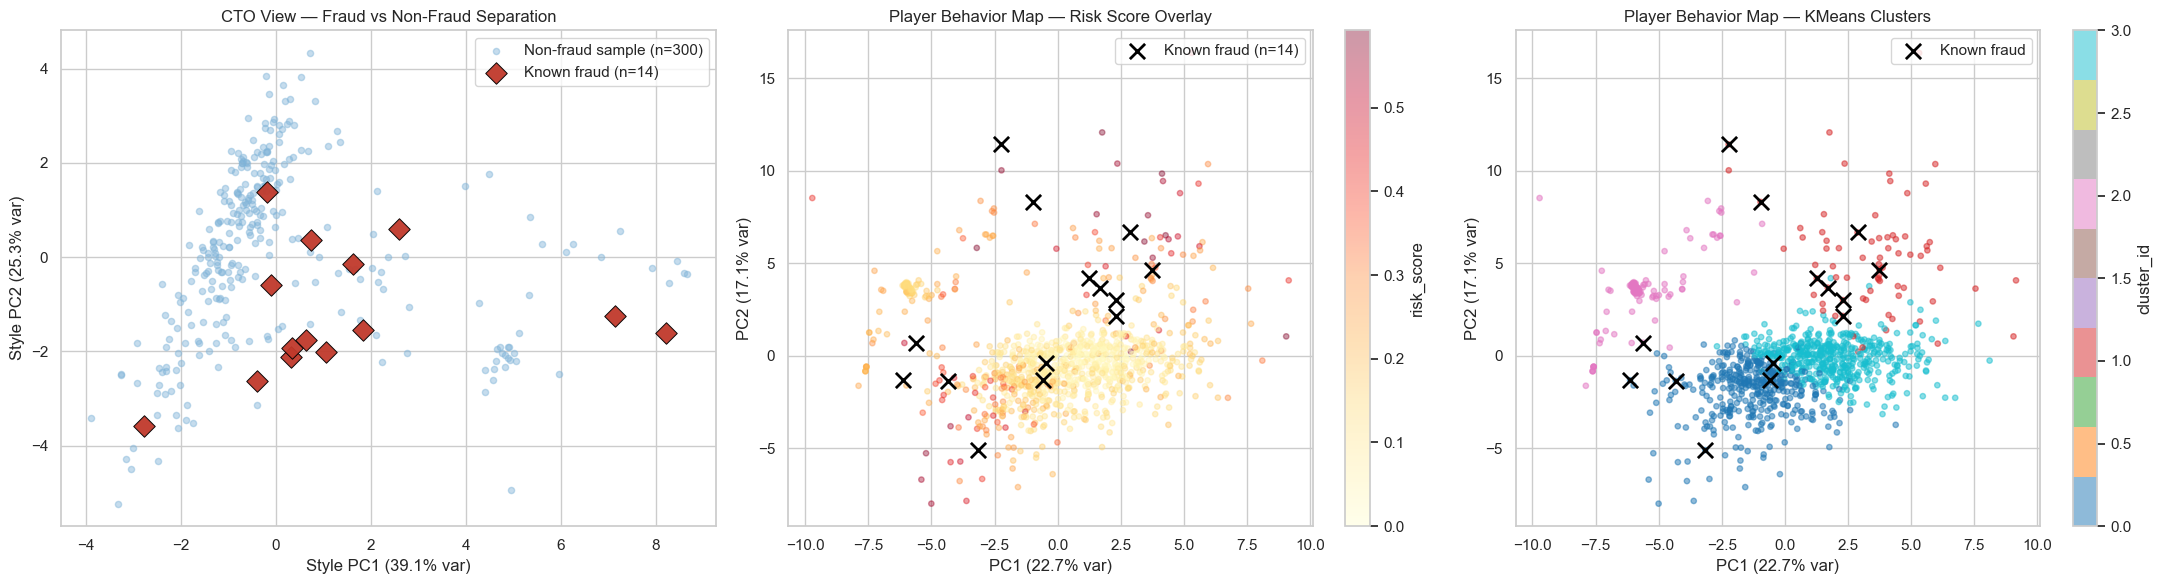

Full-feature PCA explains 39.7% of variance with 2 components.
CTO style-PCA explains 64.3% of variance with 2 components.
Fraud players are 1.3x more spread out than non-fraud along the CTO-view style PC1.
The left-hand plot is the CTO-facing separation view: non-fraud shown as a background cluster, fraud highlighted on top.


In [42]:
# Dedicated behavior-style PCA for the CTO-facing separation view
style_cols = [
    col
    for col in [
        "draws_played",
        "avg_stake_per_draw",
        "avg_nonzero_bets_per_draw",
        "avg_max_bet_share",
        "avg_entropy",
        "avg_gini",
        "avg_tiny_bet_ratio",
        "avg_position_coverage",
        "template_reuse_ratio",
        "max_template_reuse",
        "stake_cv",
        "avg_inter_draw_seconds",
        "positive_draw_rate",
    ]
    if col in X_raw.columns
]

style_df = X_raw[style_cols].copy()
for col in ["draws_played", "avg_stake_per_draw", "max_template_reuse", "avg_inter_draw_seconds"]:
    if col in style_df.columns:
        style_df[col] = np.log1p(style_df[col].clip(lower=0))
style_df = style_df.replace([np.inf, -np.inf], np.nan).fillna(0)

style_scaler = StandardScaler()
style_scaled = style_scaler.fit_transform(style_df)
pca_cto = PCA(n_components=2)
style_coords = pca_cto.fit_transform(style_scaled)
player_agg["style_pc1"] = style_coords[:, 0]
player_agg["style_pc2"] = style_coords[:, 1]

# Full-feature PCA for risk and cluster overlays
pca = PCA(n_components=2)
pc_coords = pca.fit_transform(X_scaled)
player_agg["pc1"] = pc_coords[:, 0]
player_agg["pc2"] = pc_coords[:, 1]

fraud_mask = player_agg["event_fraud_flag"] == 1
nonfraud_mask = ~fraud_mask
var_explained = pca.explained_variance_ratio_
style_var_explained = pca_cto.explained_variance_ratio_

comparison_n = min(int(nonfraud_mask.sum()), max(300, int(fraud_mask.sum()) * 10))
nonfraud_sample = player_agg.loc[nonfraud_mask].sample(n=comparison_n, random_state=RANDOM_SEED)
cto_view = pd.concat([nonfraud_sample, player_agg.loc[fraud_mask]], ignore_index=True)

fraud_style_pc1_std = player_agg.loc[fraud_mask, "style_pc1"].std()
nonfraud_style_pc1_std = player_agg.loc[nonfraud_mask, "style_pc1"].std()
style_spread_ratio = fraud_style_pc1_std / max(nonfraud_style_pc1_std, 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Left: CTO-friendly fraud vs non-fraud separation view
axes[0].scatter(
    cto_view.loc[cto_view["event_fraud_flag"] == 0, "style_pc1"],
    cto_view.loc[cto_view["event_fraud_flag"] == 0, "style_pc2"],
    s=20,
    color="#7fb3d8",
    alpha=0.45,
    label=f"Non-fraud sample (n={comparison_n})",
)
axes[0].scatter(
    cto_view.loc[cto_view["event_fraud_flag"] == 1, "style_pc1"],
    cto_view.loc[cto_view["event_fraud_flag"] == 1, "style_pc2"],
    s=120,
    color="#c0392b",
    edgecolor="black",
    linewidth=0.7,
    marker="D",
    alpha=0.95,
    label=f"Known fraud (n={int(fraud_mask.sum())})",
)
axes[0].set_xlabel(f"Style PC1 ({style_var_explained[0]:.1%} var)")
axes[0].set_ylabel(f"Style PC2 ({style_var_explained[1]:.1%} var)")
axes[0].set_title("CTO View — Fraud vs Non-Fraud Separation")
axes[0].legend(loc="upper right")

# Middle: colored by operational risk score
sc = axes[1].scatter(
    player_agg.loc[nonfraud_mask, "pc1"],
    player_agg.loc[nonfraud_mask, "pc2"],
    c=player_agg.loc[nonfraud_mask, "risk_score"],
    cmap="YlOrRd",
    alpha=0.4,
    s=15,
    vmin=0,
    vmax=player_agg["risk_score"].quantile(0.99),
)
axes[1].scatter(
    player_agg.loc[fraud_mask, "pc1"],
    player_agg.loc[fraud_mask, "pc2"],
    marker="x",
    s=120,
    c="black",
    linewidths=2,
    label=f"Known fraud (n={int(fraud_mask.sum())})",
)
plt.colorbar(sc, ax=axes[1], label="risk_score")
axes[1].legend(loc="upper right")
axes[1].set_xlabel(f"PC1 ({var_explained[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({var_explained[1]:.1%} var)")
axes[1].set_title("Player Behavior Map — Risk Score Overlay")

# Right: colored by cluster
sc2 = axes[2].scatter(
    player_agg["pc1"],
    player_agg["pc2"],
    c=player_agg["cluster_id"],
    cmap="tab10",
    alpha=0.5,
    s=15,
)
axes[2].scatter(
    player_agg.loc[fraud_mask, "pc1"],
    player_agg.loc[fraud_mask, "pc2"],
    marker="x",
    s=120,
    c="black",
    linewidths=2,
    label="Known fraud",
)
plt.colorbar(sc2, ax=axes[2], label="cluster_id")
axes[2].legend(loc="upper right")
axes[2].set_xlabel(f"PC1 ({var_explained[0]:.1%} var)")
axes[2].set_ylabel(f"PC2 ({var_explained[1]:.1%} var)")
axes[2].set_title("Player Behavior Map — KMeans Clusters")

plt.tight_layout()
plt.show()

print(f"Full-feature PCA explains {sum(var_explained):.1%} of variance with 2 components.")
print(f"CTO style-PCA explains {sum(style_var_explained):.1%} of variance with 2 components.")
print(f"Fraud players are {style_spread_ratio:.1f}x more spread out than non-fraud along the CTO-view style PC1.")
print("The left-hand plot is the CTO-facing separation view: non-fraud shown as a background cluster, fraud highlighted on top.")

### 5b.1 Descriptive Full-Behaviour PCA vs Leakage-Safe Pre-Fraud PCA

This comparison is intentionally explicit:

- **Left panel** reproduces the old EDA-style descriptive view using each player's full observed behaviour.
- **Right panel** uses the current leakage-safe pre-fraud feature table.
- The left panel is useful for storytelling and exploratory pattern recognition.
- The right panel is the one that matters for detection, because it only uses what was knowable before the fraud event.

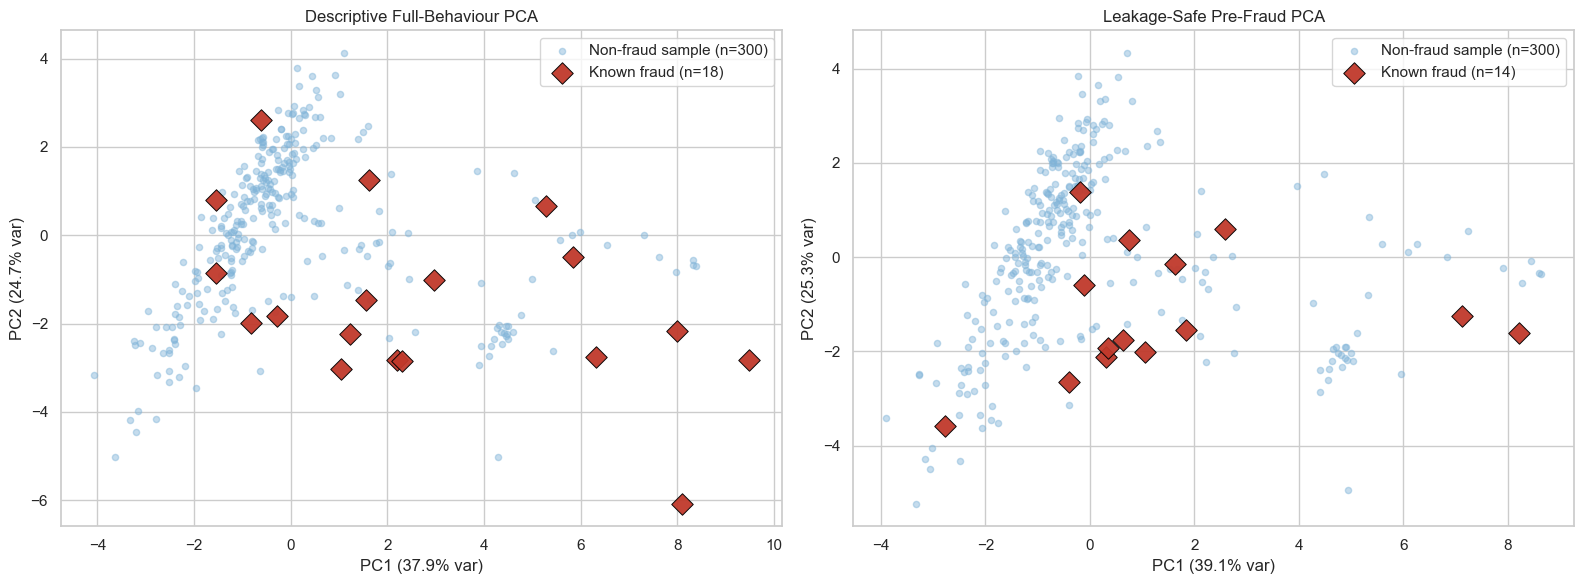

Why the left plot usually looks cleaner:
  - it uses each fraud player's full observed behaviour, including post-fraud periods
  - it is descriptive, not predictive

Descriptive full-behaviour spread ratio : 1.6x
Leakage-safe pre-fraud spread ratio     : 1.3x
Interpretation: if the descriptive ratio is much larger, the earlier EDA separation was mainly a full-history effect, not a bug in the current notebook.


In [44]:
# Build a descriptive full-behaviour player table to mirror the old EDA-style view.
# This uses the full observed timeline for each player and is intentionally NOT leakage-safe.

full_behavior_player = roulette_df.groupby("member_id").agg(
    draws_played=("draw_id", "nunique"),
    avg_stake_per_draw=("total_bet_amount", "mean"),
    avg_nonzero_bets_per_draw=("nonzero_bets_per_draw", "mean"),
    avg_max_bet_share=("max_bet_share_in_draw", "mean"),
    avg_entropy=("entropy_in_draw", "mean"),
    avg_gini=("gini_in_draw", "mean"),
    avg_tiny_bet_ratio=("tiny_bet_ratio_in_draw", "mean"),
    avg_position_coverage=("position_coverage", "mean"),
    stake_cv=("total_bet_amount", lambda x: float(x.std() / max(x.mean(), 1e-9)) if len(x) > 1 else 0.0),
    avg_inter_draw_seconds=("inter_draw_seconds", "mean"),
    positive_draw_rate=("net_result", lambda x: float((x > 0).mean())),
    unique_templates=("bet_template", "nunique"),
).reset_index()

full_template_reuse = (
    roulette_df.groupby("member_id")["bet_template"]
    .agg(
        max_template_reuse=lambda s: int(s.value_counts().iloc[0]) if len(s) else 0,
        draws_total="count",
    )
    .reset_index()
)
full_behavior_player = full_behavior_player.merge(full_template_reuse, on="member_id", how="left")
full_behavior_player["template_reuse_ratio"] = (
    1 - (full_behavior_player["unique_templates"] / full_behavior_player["draws_total"].replace(0, np.nan))
).fillna(0).clip(lower=0)
full_behavior_player["fraud_flag"] = full_behavior_player["member_id"].isin(fraud_player_set).astype(int)

descriptive_style_cols = [c for c in style_cols if c in full_behavior_player.columns]
descriptive_style_df = full_behavior_player[descriptive_style_cols].copy()
for col in ["draws_played", "avg_stake_per_draw", "max_template_reuse", "avg_inter_draw_seconds"]:
    if col in descriptive_style_df.columns:
        descriptive_style_df[col] = np.log1p(descriptive_style_df[col].clip(lower=0))
descriptive_style_df = descriptive_style_df.replace([np.inf, -np.inf], np.nan).fillna(0)

descriptive_scaler = StandardScaler()
descriptive_scaled = descriptive_scaler.fit_transform(descriptive_style_df)
descriptive_pca = PCA(n_components=2)
descriptive_coords = descriptive_pca.fit_transform(descriptive_scaled)
full_behavior_player["desc_pc1"] = descriptive_coords[:, 0]
full_behavior_player["desc_pc2"] = descriptive_coords[:, 1]

desc_fraud_mask = full_behavior_player["fraud_flag"] == 1
desc_nonfraud_mask = ~desc_fraud_mask
desc_comparison_n = min(int(desc_nonfraud_mask.sum()), max(300, int(desc_fraud_mask.sum()) * 10))
desc_nonfraud_sample = full_behavior_player.loc[desc_nonfraud_mask].sample(n=desc_comparison_n, random_state=RANDOM_SEED)
desc_view = pd.concat([desc_nonfraud_sample, full_behavior_player.loc[desc_fraud_mask]], ignore_index=True)

current_view = cto_view.copy()

desc_spread_ratio = full_behavior_player.loc[desc_fraud_mask, "desc_pc1"].std() / max(full_behavior_player.loc[desc_nonfraud_mask, "desc_pc1"].std(), 1e-6)
current_spread_ratio = player_agg.loc[fraud_mask, "style_pc1"].std() / max(player_agg.loc[nonfraud_mask, "style_pc1"].std(), 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    desc_view.loc[desc_view["fraud_flag"] == 0, "desc_pc1"],
    desc_view.loc[desc_view["fraud_flag"] == 0, "desc_pc2"],
    s=20,
    color="#7fb3d8",
    alpha=0.45,
    label=f"Non-fraud sample (n={desc_comparison_n})",
)
axes[0].scatter(
    desc_view.loc[desc_view["fraud_flag"] == 1, "desc_pc1"],
    desc_view.loc[desc_view["fraud_flag"] == 1, "desc_pc2"],
    s=120,
    color="#c0392b",
    edgecolor="black",
    linewidth=0.7,
    marker="D",
    alpha=0.95,
    label=f"Known fraud (n={int(desc_fraud_mask.sum())})",
)
axes[0].set_title("Descriptive Full-Behaviour PCA")
axes[0].set_xlabel(f"PC1 ({descriptive_pca.explained_variance_ratio_[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({descriptive_pca.explained_variance_ratio_[1]:.1%} var)")
axes[0].legend(loc="upper right")

axes[1].scatter(
    current_view.loc[current_view["event_fraud_flag"] == 0, "style_pc1"],
    current_view.loc[current_view["event_fraud_flag"] == 0, "style_pc2"],
    s=20,
    color="#7fb3d8",
    alpha=0.45,
    label=f"Non-fraud sample (n={comparison_n})",
)
axes[1].scatter(
    current_view.loc[current_view["event_fraud_flag"] == 1, "style_pc1"],
    current_view.loc[current_view["event_fraud_flag"] == 1, "style_pc2"],
    s=120,
    color="#c0392b",
    edgecolor="black",
    linewidth=0.7,
    marker="D",
    alpha=0.95,
    label=f"Known fraud (n={int(fraud_mask.sum())})",
)
axes[1].set_title("Leakage-Safe Pre-Fraud PCA")
axes[1].set_xlabel(f"PC1 ({style_var_explained[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({style_var_explained[1]:.1%} var)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print("Why the left plot usually looks cleaner:")
print("  - it uses each fraud player's full observed behaviour, including post-fraud periods")
print("  - it is descriptive, not predictive")
print()
print(f"Descriptive full-behaviour spread ratio : {desc_spread_ratio:.1f}x")
print(f"Leakage-safe pre-fraud spread ratio     : {current_spread_ratio:.1f}x")
print("Interpretation: if the descriptive ratio is much larger, the earlier EDA separation was mainly a full-history effect, not a bug in the current notebook.")

### 5c. Component Contribution & High-Risk Non-Fraud Players

In [20]:
top20 = player_agg.nlargest(20, "risk_score")[
    ["member_id","risk_score","anomaly_score","supervised_score",
     "event_fraud_flag","risk_tier","cluster_id"]
].copy().reset_index(drop=True)

top20["anomaly_contribution"]    = (ANOMALY_WEIGHT    * top20["anomaly_score"]    / top20["risk_score"]).round(3)
top20["supervised_contribution"] = (SUPERVISED_WEIGHT * top20["supervised_score"] / top20["risk_score"]).round(3)

print("Top 20 by risk_score — component contributions:")
display(top20)

print()
# High-risk but NOT in fraud list
high_risk_unknown = player_agg[
    (player_agg["risk_tier"] == "HIGH") &
    (player_agg["event_fraud_flag"] == 0)
].sort_values("risk_score", ascending=False)

print(f"HIGH-risk players NOT in fraud list: {len(high_risk_unknown)}")
print("These are candidates for fraud team investigation (may be undiscovered fraud, or high-rollers).")
display(high_risk_unknown.head(20)[
    ["member_id","risk_score","draws_played","total_staked",
     "avg_entropy","template_reuse_ratio","avg_tiny_bet_ratio",
     "avg_inter_draw_seconds","cluster_id"]
].reset_index(drop=True))

Top 20 by risk_score — component contributions:


,member_id,risk_score,anomaly_score,supervised_score,event_fraud_flag,risk_tier,cluster_id,anomaly_contribution,supervised_contribution
0,GK00114789,0.8915,0.8206,0.9977,1,HIGH,2,0.5520,0.4480
1,GK00114634,0.7876,0.6462,0.9996,1,HIGH,1,0.4920,0.5080
2,GK00128856,0.7821,0.9807,0.4842,0,HIGH,1,0.7520,0.2480
3,GK00551451,0.7659,0.6099,1.0000,1,HIGH,1,0.4780,0.5220
4,GK00210357,0.7490,0.5816,1.0000,0,HIGH,1,0.4660,0.5340
5,GK00521903,0.6970,0.4949,1.0000,1,HIGH,1,0.4260,0.5740
6,GK00260161,0.6637,0.7837,0.4838,0,HIGH,1,0.7080,0.2920
7,GK00123994,0.6614,0.4996,0.9040,0,HIGH,1,0.4530,0.5470
8,GK00114361,0.6473,0.4565,0.9336,1,HIGH,1,0.4230,0.5770
9,GK00252953,0.6387,0.4147,0.9746,0,HIGH,1,0.3900,0.6100



HIGH-risk players NOT in fraud list: 43
These are candidates for fraud team investigation (may be undiscovered fraud, or high-rollers).


,member_id,risk_score,draws_played,total_staked,avg_entropy,template_reuse_ratio,avg_tiny_bet_ratio,avg_inter_draw_seconds,cluster_id
0,GK00128856,0.7821,3,"20,630.0000",2.7253,0.0000,0.0000,"269,299.6880",1
1,GK00210357,0.7490,14,"4,619.0000",2.3579,0.0000,0.0143,"145,272.2484",1
2,GK00260161,0.6637,2175,"811,562.0000",4.1029,0.0069,0.0166,"3,076.7850",1
3,GK00123994,0.6614,523,"324,277.0000",4.7695,0.4608,0.4611,"12,441.1398",1
4,GK00252953,0.6387,364,"268,002.0000",3.3823,0.0220,0.0228,"17,372.9092",1
5,GK00112339,0.6299,224,"10,981.0000",5.0087,0.9330,0.9473,"7,244.8348",1
6,GK00277384,0.6256,106,"142,271.0000",4.4574,0.0472,0.0000,"45,008.1693",1
7,GK00113964,0.6220,289,"46,689.0000",3.8450,0.3426,0.3591,"22,536.1064",1
8,GK00237407,0.6136,375,"126,502.0000",4.3479,0.3760,0.3954,"18,165.8894",1
9,GK00277420,0.5730,135,"365,507.0000",3.2303,0.0000,0.0025,"33,489.4705",1


---
## Section 6 — Save Outputs

In [45]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

# 1. Full scored player table
player_agg.to_parquet(DATA_DIR / "hybrid_scored_players.parquet", index=False)

# 2. Alert queue (top 50 for fraud team — drop label before sharing)
alert_queue.drop(columns=["event_fraud_flag"]).to_csv(
    DATA_DIR / "alert_queue.csv", index=False
)

# 3. Evaluation metadata (use out-of-sample columns for evidence)
capture_rates = {}
for method, col in [
    ("anomaly", "anomaly_score"),
    ("supervised_oos", "supervised_score_eval"),
    ("combined_oos", "risk_score_eval"),
]:
    score_series = player_agg[col]
    fraud_series = player_agg.loc[player_agg["event_fraud_flag"] == 1, col]
    method_capture = {}
    for threshold_pct in [0.01, 0.05, 0.10, 0.20]:
        method_capture[f"top_{int(threshold_pct * 100)}pct"] = int(
            (fraud_series >= score_series.quantile(1 - threshold_pct)).sum()
        )
    capture_rates[method] = method_capture

risk_tier_distribution = {}
for tier_name, tier_count in player_agg["risk_tier"].value_counts().items():
    risk_tier_distribution[str(tier_name)] = int(tier_count)

eval_meta = {
    "total_players": len(player_agg),
    "fraud_players": int(player_agg["event_fraud_flag"].sum()),
    "usable_fraud_players_after_cutoff": int(player_agg["event_fraud_flag"].sum()),
    "dropped_positive_players": int(dropped_positive_players),
    "anomaly_weight": ANOMALY_WEIGHT,
    "supervised_weight": SUPERVISED_WEIGHT,
    "capture_rates": capture_rates,
    "risk_tier_distribution": risk_tier_distribution,
}
with open(DATA_DIR / "hybrid_evaluation.json", "w") as f:
    json.dump(eval_meta, f, indent=2, default=str)

print("Outputs saved:")
print(f"  {DATA_DIR}/hybrid_scored_players.parquet  ({len(player_agg)} players, {player_agg.shape[1]} cols)")
print(f"  {DATA_DIR}/alert_queue.csv                (top 50 players, label removed)")
print(f"  {DATA_DIR}/hybrid_evaluation.json")
print()
print("Evaluation summary:")
print(json.dumps(eval_meta, indent=2))

Outputs saved:
  ..\data_cache/hybrid_scored_players.parquet  (1045 players, 61 cols)
  ..\data_cache/alert_queue.csv                (top 50 players, label removed)
  ..\data_cache/hybrid_evaluation.json

Evaluation summary:
{
  "total_players": 1045,
  "fraud_players": 14,
  "usable_fraud_players_after_cutoff": 14,
  "dropped_positive_players": 4,
  "anomaly_weight": 0.6,
  "supervised_weight": 0.4,
  "capture_rates": {
    "anomaly": {
      "top_1pct": 3,
      "top_5pct": 6,
      "top_10pct": 7,
      "top_20pct": 10
    },
    "supervised_oos": {
      "top_1pct": 3,
      "top_5pct": 5,
      "top_10pct": 7,
      "top_20pct": 9
    },
    "combined_oos": {
      "top_1pct": 3,
      "top_5pct": 6,
      "top_10pct": 9,
      "top_20pct": 12
    }
  },
  "risk_tier_distribution": {
    "LOW": 836,
    "MEDIUM": 156,
    "HIGH": 53
  }
}


---
## Section 7 — Conclusions & Honest Assessment

### What this system CAN do
- **Rank players by behavioral abnormality** relative to the analysis cohort.
- **Surface high-risk players** for human review at a tunable threshold.
- **Show a clear PCA-based behavior map** where most non-fraud players sit in a dense core while known fraud players are visibly more dispersed and outlying.
- **Combine two independent signals**: anomaly detection (how unusual) plus supervised pattern matching (how similar to known fraud).

### What this system CANNOT do (yet)
- **Reliably classify** individual players as fraud or non-fraud. The positive class is still tiny, and each one in the held-out test set changes recall by 25%.
- **Generalize beyond 14 known fraud patterns.** Novel fraud may only be caught if it also appears behaviorally unusual.
- **Guarantee that high anomaly means fraud.** High-rollers, professionals, or automation-assisted legitimate play can also look unusual.
- **Score relative to the full platform.** The current cohort is biased toward fraud-adjacent players.

### How to read the notebook honestly
- Use the **capture-rate table** as the evidence section. It now uses out-of-sample supervised and combined scores.
- Use the **alert queue** as the operational section. It uses the best current ranking score fitted on all available labels for this cohort.
- Use the **CTO PCA plot** as a visual aid, not as proof of separability.

### What improves this system
1. More confirmed labels from fraud team review of the alert queue.
2. A full population extract to recalibrate the anomaly baseline.
3. Stronger temporal features once coverage improves.
4. Graph or network features later if coordinated behavior becomes a priority.

### Recommended operating mode
- Ship the alert queue to the fraud team weekly.
- Track confirm and reject decisions per member ID.
- Re-train monthly as confirmed labels accumulate.
- Keep stakeholder claims tied to the out-of-sample capture table, not the operational queue metrics.

### One-line summary for stakeholders
This notebook builds a leakage-safe hybrid ranking system: anomaly detection is the primary signal, known-fraud matching is secondary, and all evaluation claims are relative to the current analysis cohort rather than the full platform.